In [1]:
import GWDALI as gw
import numpy as np
import matplotlib.pyplot as plt

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Setting Detectors Network

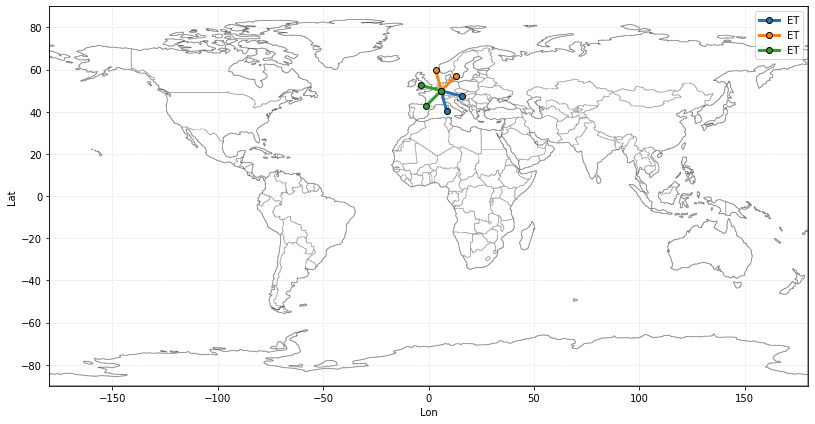

In [2]:
det_ET1 = {'name':'ET','lon':6, 'lat':50, 'rot':0, 'shape':60}
det_ET2 = {'name':'ET','lon':6, 'lat':50, 'rot':120, 'shape':60}
det_ET3 = {'name':'ET','lon':6, 'lat':50, 'rot':-120, 'shape':60}
detectors = [det_ET1, det_ET2, det_ET3]

fig = gw.draw_detectors(detectors)

## Setting GW source parameters

For GW Polarizations computing it is necessary to declare **15 parameters** (see [https://gwdali.readthedocs.io/en/latest/gw_sources.html](https://gwdali.readthedocs.io/en/latest/gw_sources.html) ):

* Mass parameters: 2 
    * {m1, m2, Mc, eta, M, q, deltaM, inv_eta, ln_eta, ln_Mc}
* Distance Parameters: 1 
    * {dL, inv_dL, inv_dL2, inv_sqrtdL, lnDL, inv_lnDL}
* Spins Parameters: 6 
    * (Cartesian / Spherical / Symmetric-Antisymmetric)
* Extrinsic Parameters: 6 
    * (iota/cos_iota , phi_coal, t_coal, RA, Dec, psi)

In [3]:
GwPrms = {}                                                                                                
GwPrms['dL'] 	= 10.96
GwPrms['Mc'] 	= 9.57
GwPrms['eta'] 	= 0.25
GwPrms['iota'] 	= 0.52
GwPrms['psi'] 	= 2.32
GwPrms['t_coal'] 	= 0.00
GwPrms['phi_coal'] 	= -1.37
GwPrms['RA'] 	= -135.75
GwPrms['Dec'] 	= 72.92
GwPrms['sz1'] 	= 0.31
GwPrms['sz2'] 	= 0.16

GwPrms['sx1'] 	= 0.00
GwPrms['sy1'] 	= 0.00

GwPrms['sx2'] 	= 0.00
GwPrms['sy2'] 	= 0.00

### Computing DALI tensors for Triplet

$$F_{ij} \equiv \langle \partial_i h| \partial_j h\rangle$$
$$D_{ijk} \equiv \langle \partial_i h| \partial_{jk} h\rangle$$
$$D_{ijkl} \equiv \langle \partial_{ij} h| \partial_{kl} h\rangle$$
$$T_{ijkl} \equiv \langle \partial_i h| \partial_{jkl} h\rangle$$
$$T_{ijklm} \equiv \langle \partial_{ij} h| \partial_{klm} h\rangle$$
$$T_{ijklmn} \equiv \langle \partial_{ijk} h| \partial_{lmn} h\rangle$$

In [4]:
res = gw.get_dali_tensors(  GwPrms=GwPrms,
                            detectors=detectors,
                            FreeParams=["dL","iota"],
                            method = "Triplet",
                            approx = "IMRPhenomD",                            
                            enable_jax_waveforms = True,
                            diff_method = "autodiff",
                            jitgrad = False,
                        )

Tensors, time_dets_tns = res


*********************************** [1] Detector: ET ***********************************

	 loading <autodiff> derivatives ...
		>> jitgrad = False...
	 <autodiff> derivatives loaded!


==================================== Computing DALI Tensors (Triplet) ====================================



 # Computing First-Order Derivatives (diff_method = autodiff) .....

	 (dL)	 [1-2]	 Diff[dL] OK! 	(3 seconds)
	 (iota)	 [2-2]	 Diff[iota] OK! 	(1 seconds)

>> First Derivatives Concluded in 0min:4sec!



	Fisher(1|1) [1,1] ..............................

Computing Second-Order Derivatives ...
	 (dL,dL)	 [1-3]	 Diff[dL,dL] OK! 	(1 seconds)
	 (iota,dL)	 [2-3]	 Diff[iota,dL] OK! 	(1 seconds)
	 (iota,iota)	 [3-3]	 Diff[iota,iota] OK! 	(2 seconds)

>> Second Derivatives Concluded in 0min:5sec!



Doublet(1|2) [(1, 1, 1)]  ..............................
Doublet(2|2) [(1, 1, 1, 1)]  ..............................

Computing Third-Order Derivatives...
	 (dL,dL,dL)	 [1-4]	 Diff[dL,dL,dL] OK! 	(1 seconds

### Showing Outputs

In [5]:
Fisher = Tensors["Fisher"]
Doublet = Tensors["Doublet"] 
Triplet = Tensors["Triplet"]

Db12, Db22 = Doublet
Tp13, Tp23, Tp33 = Triplet

AllTensors = [Fisher,*Doublet,*Triplet]
for a in AllTensors:
    print(np.shape(a))

(2, 2)
(2, 2, 2)
(2, 2, 2, 2)
(2, 2, 2, 2)
(2, 2, 2, 2, 2)
(2, 2, 2, 2, 2, 2)


In [6]:
# len(time_dets_tns) = len(detectors)

for n, time_det in enumerate(time_dets_tns):
    print('\n',"---"*10,f"Detector ({n+1})","---"*10)
    time_diffs, time_tns = time_det
    
    time_diff1_array, total_time_diff1 = time_diffs[0]
    time_diff2_array, total_time_diff2 = time_diffs[1]
    time_diff3_array, total_time_diff3 = time_diffs[2]

    print("Number of independents 1st derivatives:",len(time_diff1_array), f"; Total Time (1st diffs) = {total_time_diff1:.2f} seconds") 
    print("Number of independents 2nd derivatives:",len(time_diff2_array), f"; Total Time (2nd diffs) = {total_time_diff2:.2f} seconds") 
    print("Number of independents 3rd derivatives:",len(time_diff3_array), f"; Total Time (3rd diffs) = {total_time_diff3:.2f} seconds")


 ------------------------------ Detector (1) ------------------------------
Number of independents 1st derivatives: 2 ; Total Time (1st diffs) = 4.92 seconds
Number of independents 2nd derivatives: 3 ; Total Time (2nd diffs) = 5.90 seconds
Number of independents 3rd derivatives: 4 ; Total Time (3rd diffs) = 7.82 seconds

 ------------------------------ Detector (2) ------------------------------
Number of independents 1st derivatives: 2 ; Total Time (1st diffs) = 3.24 seconds
Number of independents 2nd derivatives: 3 ; Total Time (2nd diffs) = 4.65 seconds
Number of independents 3rd derivatives: 4 ; Total Time (3rd diffs) = 6.72 seconds

 ------------------------------ Detector (3) ------------------------------
Number of independents 1st derivatives: 2 ; Total Time (1st diffs) = 3.28 seconds
Number of independents 2nd derivatives: 3 ; Total Time (2nd diffs) = 4.70 seconds
Number of independents 3rd derivatives: 4 ; Total Time (3rd diffs) = 6.50 seconds


### Saving Tensors

In [7]:
np.savez_compressed("DaliTensors.npz",Fisher=Fisher, Db12=Db12, Db22=Db22, Tp13=Tp13, Tp23=Tp23, Tp33=Tp33)